In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import sys
from wave_approx import *

%load_ext autoreload
%autoreload 2

/home/wd/repo/spont_approx/wave_approx.py:6: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [3]:
quad = False
rLTD = 1.0
r0 = 6
rx = 20
l = 8
d = 3
v = 3.2
k = 0.114*0.017
A = 0.01
tau_m = 0.02
tau = 1
gL = 40
nT = 20
nt = 8000
w0 = 0.1
cap = 12
theme = 'gLs'
square = True
if not square:
    half_func = half_circle_height
    iint_func = iint_circle_chord
    int_func = int_circle_chord
    if quad:
        func = half_circle_height
    else:
        func = iint_circle_chord
else:
    half_func = half_square
    iint_func = iint_square
    int_func = int_square
    if quad:
        func = half_square
    else:
        func = iint_square
 

T = 16.017, dt = 1.602e-01, each LGN activated for 11.7%
max weight possible: 3.600e+00
using method exact1
5/5... T = 16.017, dt = 1.602e-02, each LGN activated for 11.7%
max weight possible: 3.600e+00
using method exact1
5/5... T = 16.017, dt = 1.602e-03, each LGN activated for 11.7%
max weight possible: 3.600e+00
using method exact1
5/5... T = 16.017, dt = 1.602e-04, each LGN activated for 11.7%
max weight possible: 3.600e+00
using method exact1
5/5... 

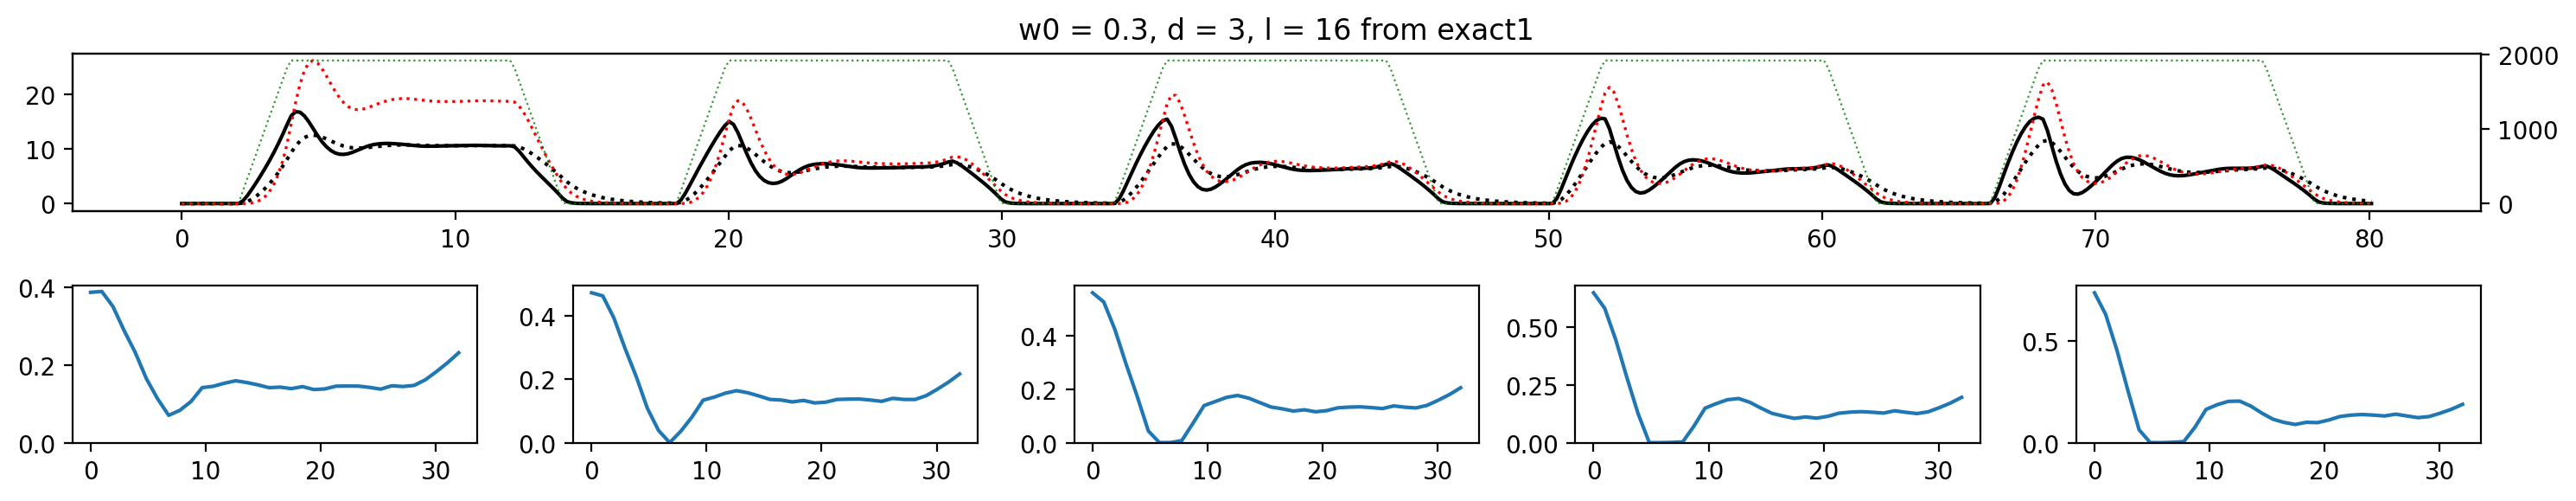

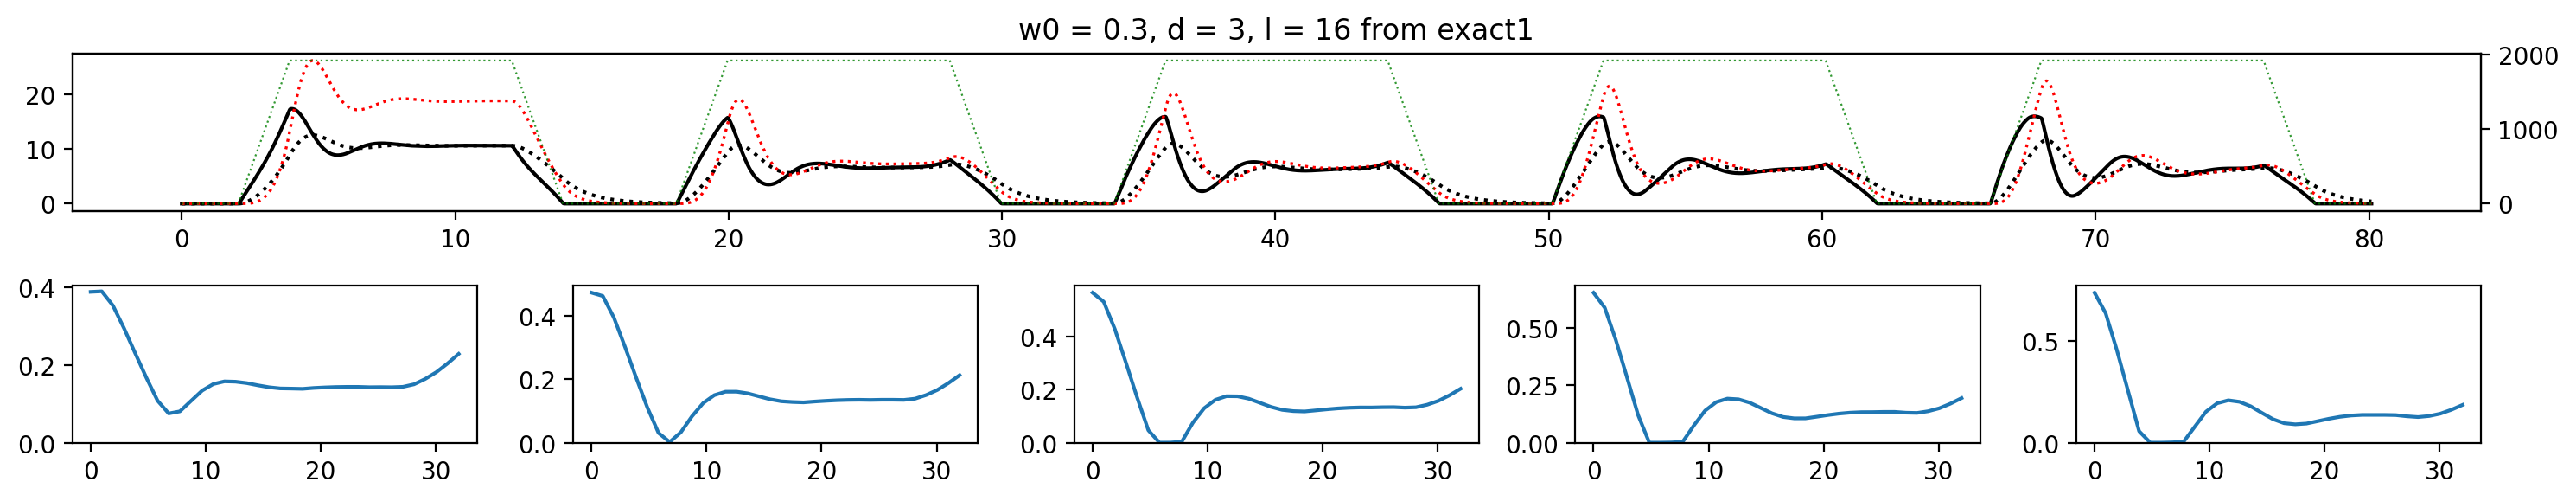

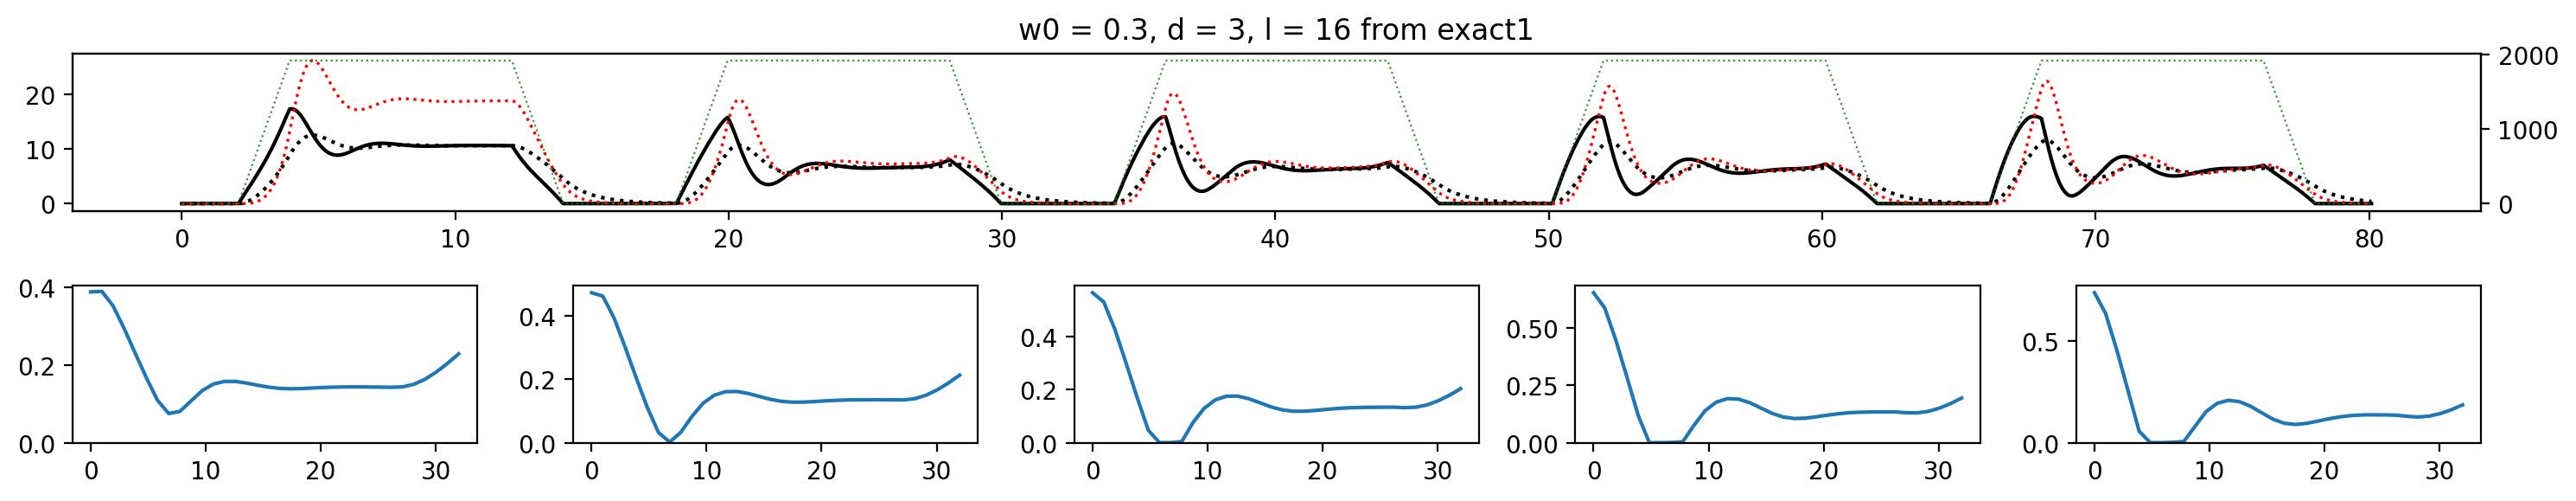

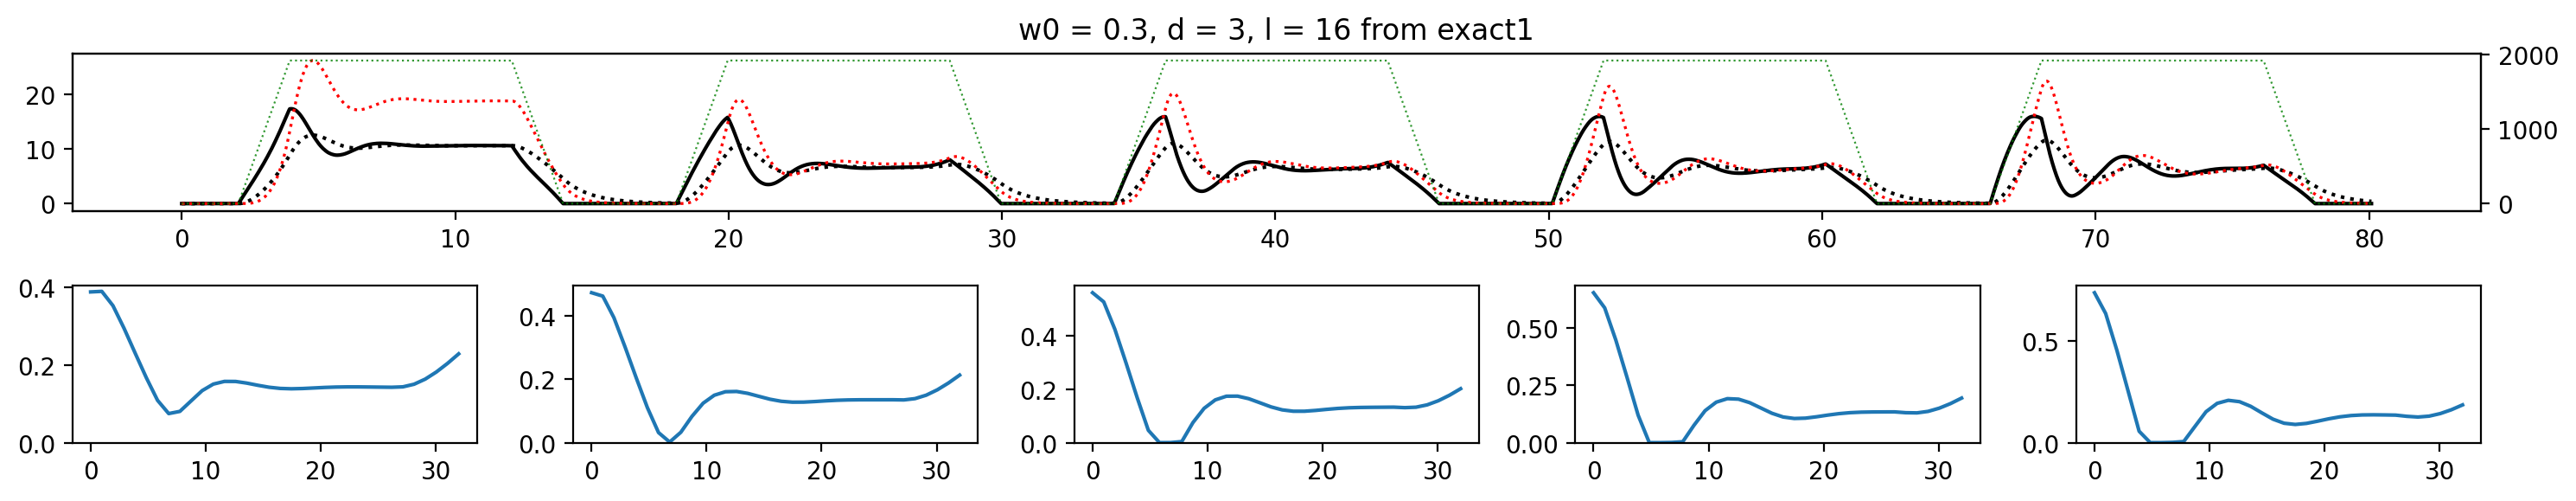

In [5]:
# numerical error test
pt = 4
fork_ivp = True 
fr = [None]*pt
for i in range(pt):
    wt1, fr[i], rbar1 = iter_sweep('exact1', nT = nT, w0 = w0, l = l, d = d, v = v, k = k, A = A, rLTD = rLTD, r0 = r0, rx = rx, tau = tau, tau_m = tau_m, gL = gL, cap = cap, nt = 100*np.power(10,i), plot = True, theme = f'{theme}_{i}', fork_ivp = fork_ivp)

[-1.86110323e-03  1.06897332e-04 -3.47578237e-05]
[  500  5000 50000]


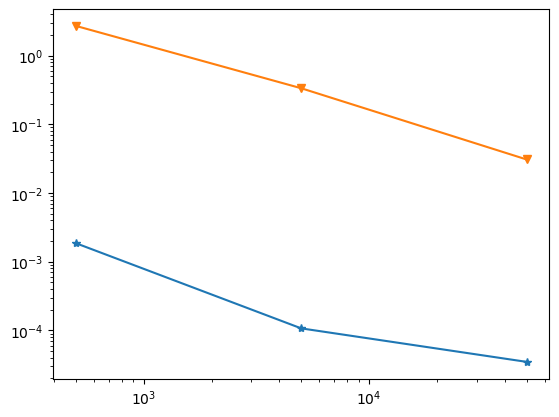

In [6]:
err = np.zeros((pt-1,3))
nt_max = 100*np.power(10,pt-1)*nT + 1
assert(nt_max == len(fr[-1]))
for i in range(pt-1):
    err[i,0] = np.mean(fr[i] - fr[-1][0:nt_max:np.power(10,pt-i-1)])
    err[i,1] = np.max(np.abs(fr[i] - fr[-1][0:nt_max:np.power(10,pt-i-1)]))
    err[i,2] = np.min(np.abs(fr[i] - fr[-1][0:nt_max:np.power(10,pt-i-1)]))

fig, ax = plt.subplots()
#ax.errorbar(100*np.power(10,np.arange(pt-1)), err[:,0], err[:,1], marker = '*', capsize = 4)
print(err[:,0])
ax.loglog(100*np.power(10,np.arange(pt-1))*nT, np.abs(err[:,0]), '-*')
ax.loglog(100*np.power(10,np.arange(pt-1))*nT, np.abs(err[:,1]), '-v')
ax.loglog(100*np.power(10,np.arange(pt-1))*nT, np.abs(err[:,2]), '-^')
print(100*np.power(10,np.arange(pt-1))*nT)

(-0.05, 0.15)

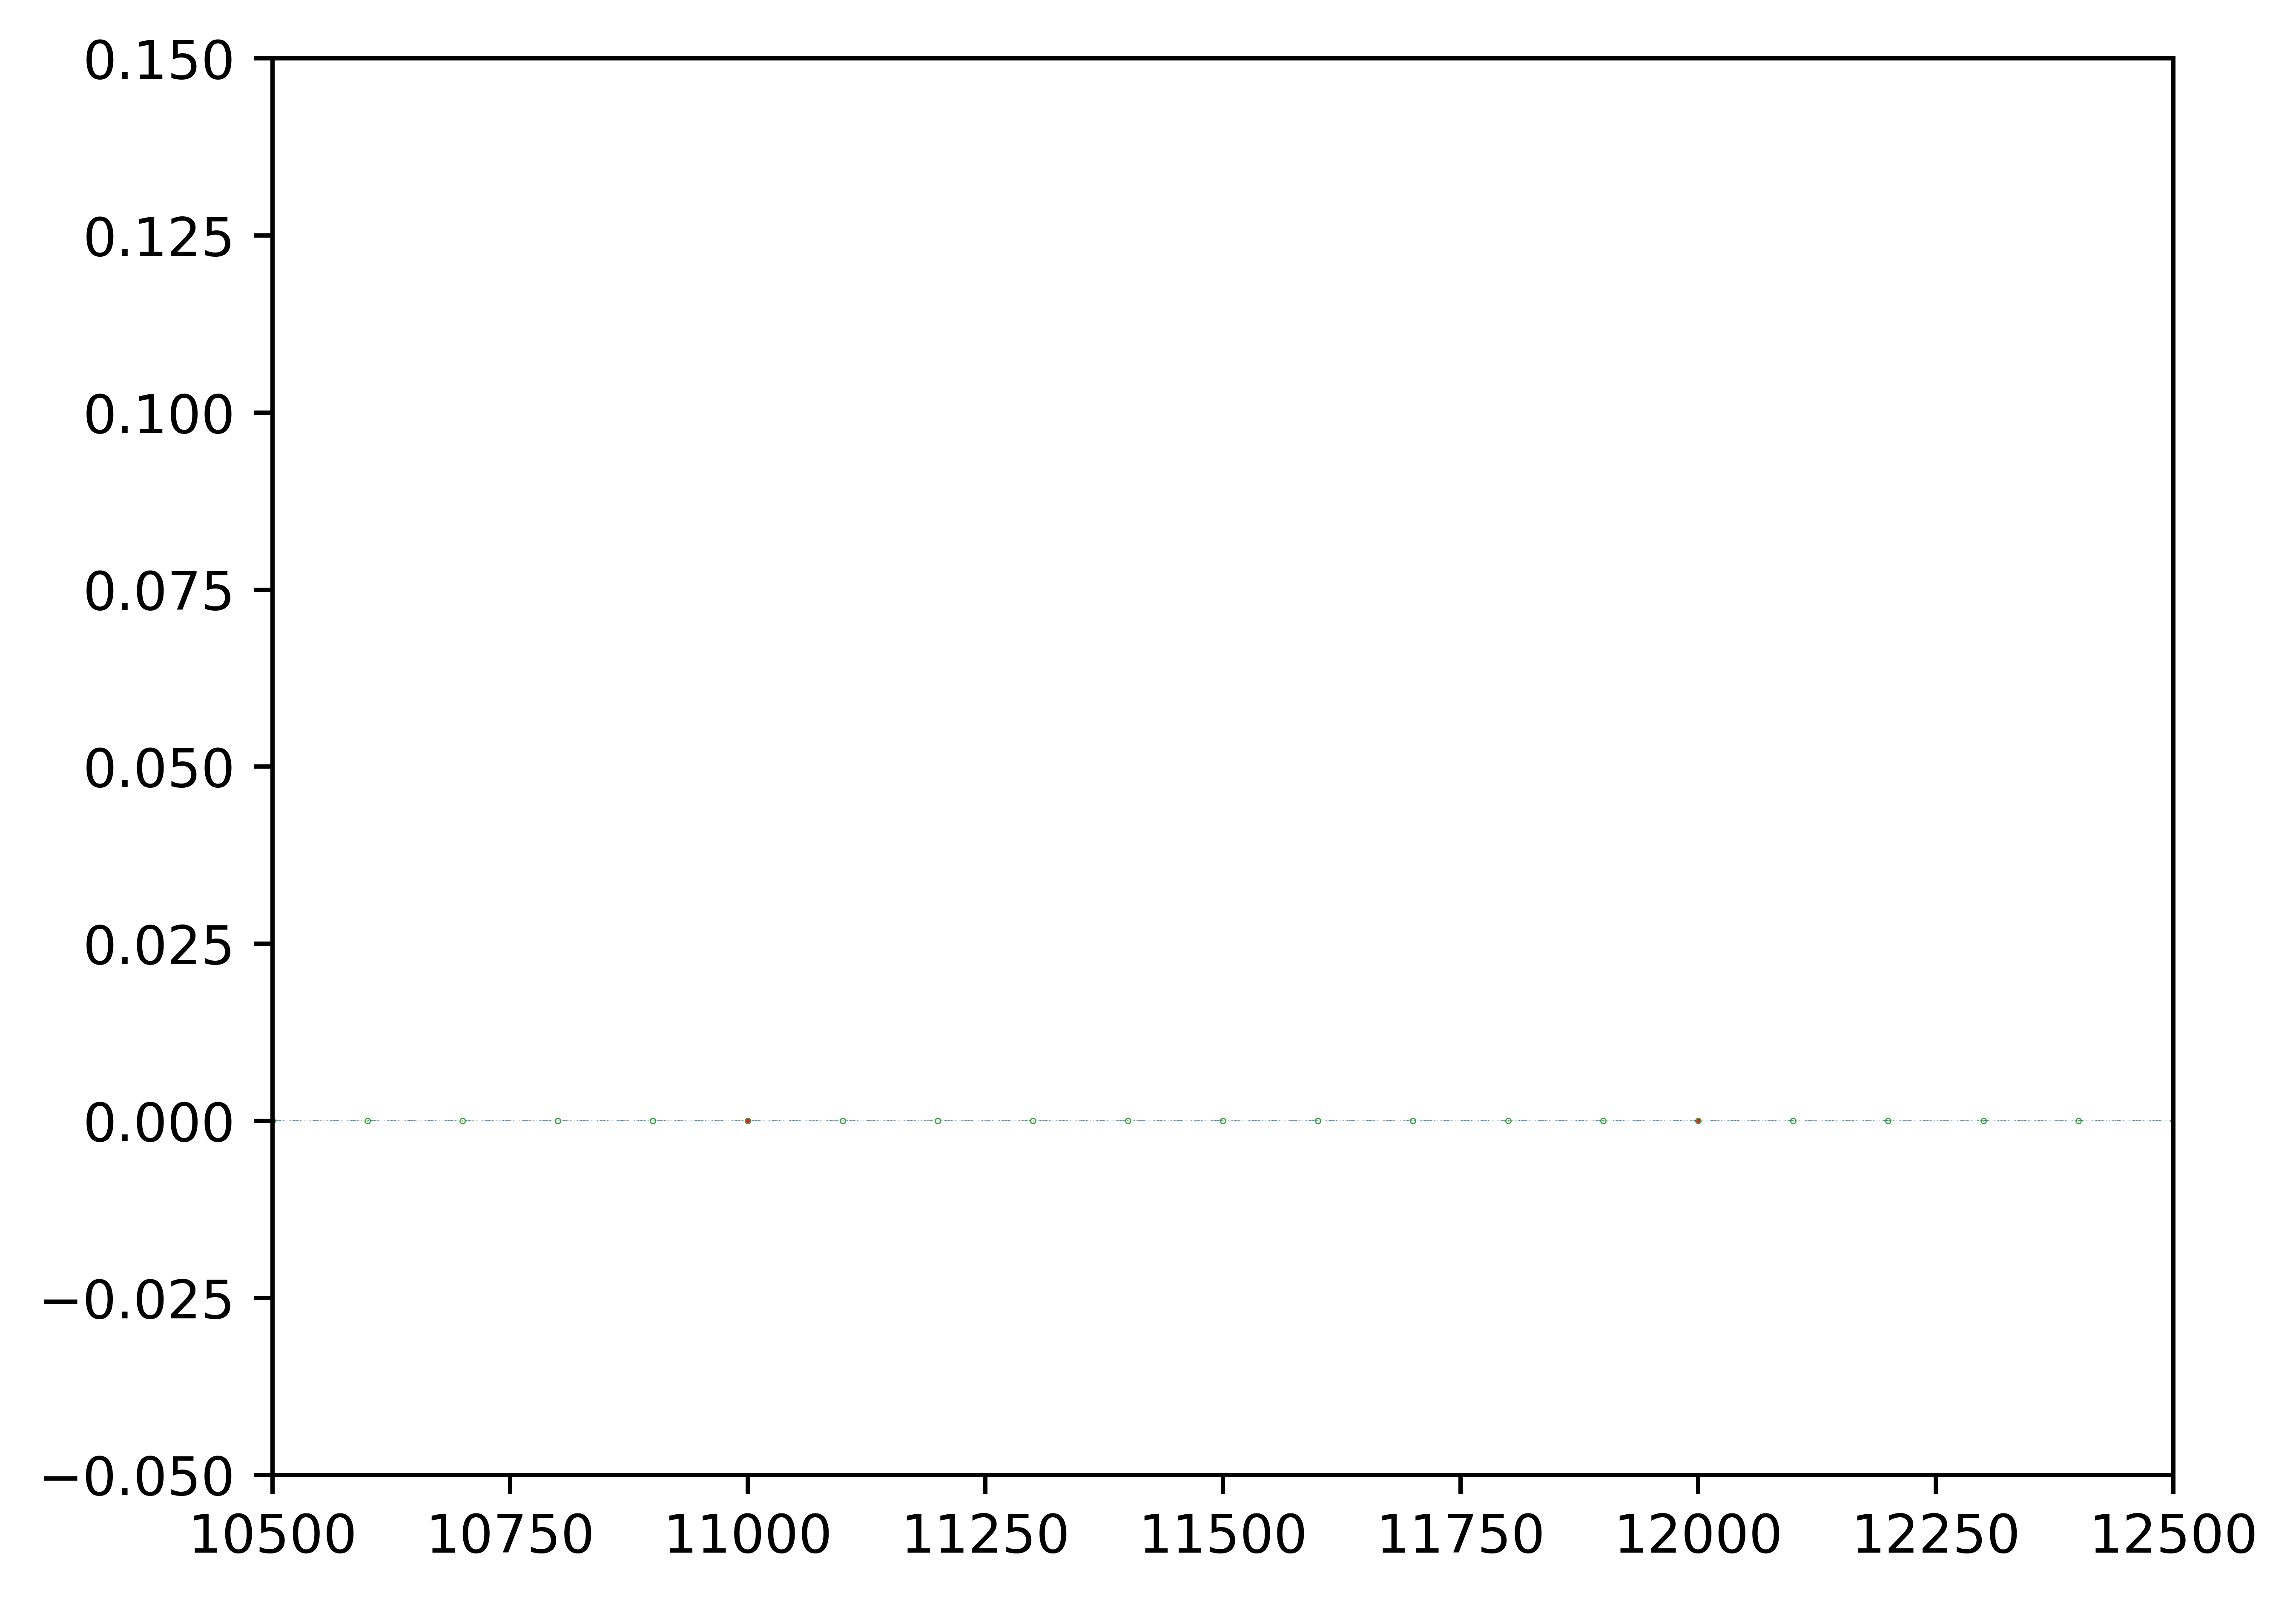

In [7]:
fig, ax = plt.subplots(dpi = 900)
ax.plot(np.arange(nT*100*np.power(10,pt-1) +1),fr[-1], ',')
ax.plot(np.arange(nT*100*np.power(10,2)+1)*np.power(10,pt-3),fr[2], ',')
ax.plot(np.arange(nT*100*np.power(10,1)+1)*np.power(10,pt-2),fr[1], 'o', ms = 0.2)
ax.plot(np.arange(nT*100*np.power(10,0)+1)*np.power(10,pt-1),fr[0], '*', ms = 0.2)
ax.set_xlim(10500, 12500)
ax.set_ylim(-0.05, 0.15)